# Assignment 4 (new data) — 5. Cross-dataset comparison

**This notebook trains nothing.** It reads the JSON that notebooks 01–04 wrote and answers the question the
assignment actually asks: *what changes when you implement the same model three different ways, and what
does not?*

Run notebooks 01 to 04 first. Each writes its results to `notebook/results/`; this one collects them.

MNIST stands in for the Intel scene data, whose labelled splits are absent from `data/` —
`00_inventory.ipynb` has the evidence.

| Source | Contributes |
|---|---|
| `n01_diabetes_brfss.json` | tabular MLP × 3 frameworks, plus the class-weighting experiment |
| `n02_rice_cnn.json` | rice CNN × 3 frameworks, subset and full |
| `n03_mnist_cnn.json` | MNIST CNN × 3 frameworks, subset and full |
| `n04_improved_cnn.json` | the M1→M4 ladder and the augmentation experiment |

In [1]:
import os, sys, json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath("."))
sys.path.insert(0, os.path.abspath(".."))

import ass4_newdata as D
import ass4_utils as U

RESULTS = D.notebook_results_dir()
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.width", 150)

def load(name):
    p = os.path.join(RESULTS, name)
    if not os.path.exists(p):
        print(f"  MISSING  {name}  - run the notebook that produces it")
        return None
    with open(p, encoding="utf-8") as f:
        print(f"  loaded   {name}")
        return json.load(f)

print("reading", os.path.relpath(RESULTS, D.ROOT))
n01 = load("n01_diabetes_brfss.json")
n02 = load("n02_rice_cnn.json")
n03 = load("n03_mnist_cnn.json")
n04 = load("n04_improved_cnn.json")

if n01 is None or n02 is None:
    raise SystemExit("notebooks 01 and 02 are required before this one can say anything")

reading notebook\results
  loaded   n01_diabetes_brfss.json
  loaded   n02_rice_cnn.json
  loaded   n03_mnist_cnn.json
  loaded   n04_improved_cnn.json


---
## 1. Every run in one table

The columns are the ones lecture 04, slide 29 asks to be reported.

In [2]:
rows = []
for src, payload in [("01_diabetes_brfss", n01), ("02_rice_cnn", n02),
                     ("03_mnist_cnn", n03)]:
    if payload is None:
        continue
    # notebook 03 keeps its full-data runs in a separate key, like 02_mnist.ipynb does
    for r in payload["results"] + payload.get("full_results", []):
        rows.append({"notebook": src, **{k: v for k, v in r.items()
                                         if k not in ("history", "confusion")}})

all_runs = pd.DataFrame(rows)
all_runs = all_runs[["notebook", "framework", "dataset", "model", "n_params", "epochs",
                     "train_seconds", "train_loss", "test_accuracy",
                     "precision_macro", "recall_macro", "f1_macro"]]
display(all_runs.round(4))

csv_path = os.path.join(RESULTS, "all_runs_new.csv")
all_runs.to_csv(csv_path, index=False)
print(f"\nwrote {os.path.relpath(csv_path, D.HERE)}  ({len(all_runs)} runs)")

,notebook,framework,dataset,model,n_params,epochs,train_seconds,train_loss,test_accuracy,precision_macro,recall_macro,f1_macro
0,01_diabetes_brfss,Scratch (NumPy),BRFSS diabetes 2015+2023,MLP 19-128-64-3,11011,15,27.46,0.4134,0.8403,0.4673,0.3838,0.3919
1,01_diabetes_brfss,TensorFlow/Keras,BRFSS diabetes 2015+2023,MLP 19-128-64-3,11011,15,41.92,0.4133,0.8402,0.4703,0.3768,0.3823
2,01_diabetes_brfss,PyTorch,BRFSS diabetes 2015+2023,MLP 19-128-64-3,11011,15,74.68,0.4133,0.8406,0.4686,0.3814,0.3888
3,02_rice_cnn,Scratch (NumPy),Rice (5k subset),SmallCNN 2conv+fc,544453,5,67.26,0.0715,0.9445,0.9481,0.9451,0.9444
4,02_rice_cnn,TensorFlow/Keras,Rice (5k subset),SmallCNN 2conv+fc,544453,5,5.14,0.0903,0.9545,0.9564,0.9542,0.9544
5,02_rice_cnn,PyTorch,Rice (5k subset),SmallCNN 2conv+fc,544453,5,1.42,0.0984,0.9475,0.9501,0.9477,0.9477
6,02_rice_cnn,PyTorch,Rice (full),SmallCNN 2conv+fc,544453,5,17.15,0.0337,0.9929,0.9929,0.9929,0.9929
7,02_rice_cnn,TensorFlow/Keras,Rice (full),SmallCNN 2conv+fc,544453,5,57.46,0.0244,0.9911,0.9911,0.9911,0.9911
8,03_mnist_cnn,Scratch (NumPy),MNIST (10k subset),CNN 2conv+fc,20490,5,42.68,0.0525,0.9810,0.9813,0.9810,0.9810
9,03_mnist_cnn,TensorFlow/Keras,MNIST (10k subset),CNN 2conv+fc,20490,5,6.62,0.0665,0.9755,0.9765,0.9754,0.9756



wrote results\all_runs_new.csv  (13 runs)


---
## 2. Does the framework change the model?

This is the central claim of the whole assignment. It splits into two checks that have to be made
separately, because they can fail independently:

1. **Do the three implementations build the same function?** Testable exactly, via parameter counts.
2. **Do they reach the same accuracy?** Only testable up to noise, because weight initialisation and
   shuffling order differ between them.

In [3]:
print("1. PARAMETER COUNTS - must match exactly within a dataset\n")
ok = True
for ds, grp in all_runs.groupby("dataset", sort=False):
    counts = grp["n_params"].unique()
    same = len(counts) == 1
    ok &= same
    print(f"  {ds:<28} {counts[0]:>10,}  "
          f"{'identical across ' + str(len(grp)) + ' runs' if same else 'MISMATCH ' + str(counts)}")

print(f"\n  verdict: {'all parameter counts agree' if ok else 'a mismatch exists - investigate'}")

1. PARAMETER COUNTS - must match exactly within a dataset

  BRFSS diabetes 2015+2023         11,011  identical across 3 runs
  Rice (5k subset)                544,453  identical across 3 runs
  Rice (full)                     544,453  identical across 2 runs
  MNIST (10k subset)               20,490  identical across 3 runs
  MNIST (full 60k)                 20,490  identical across 2 runs

  verdict: all parameter counts agree


In [4]:
print("2. ACCURACY - compared only within one dataset, where the data is identical\n")
spread = []
for ds, grp in all_runs.groupby("dataset", sort=False):
    if grp["framework"].nunique() < 2:
        continue
    lo, hi = grp["test_accuracy"].min(), grp["test_accuracy"].max()
    spread.append({"dataset": ds, "frameworks": grp["framework"].nunique(),
                   "min_acc": lo, "max_acc": hi, "spread": hi - lo})
spread_df = pd.DataFrame(spread)
display(spread_df.round(4))

print(f"largest framework spread anywhere: {spread_df['spread'].max():.4f} accuracy")
print("\nFor reference, 04_compare.ipynb in the original assignment measured the")
print("seed-only noise floor on one model at 0.053 accuracy across five seeds.")
print("A framework spread below that is indistinguishable from run-to-run variation.")

2. ACCURACY - compared only within one dataset, where the data is identical



,dataset,frameworks,min_acc,max_acc,spread
0,BRFSS diabetes 2015+2023,3,0.8402,0.8406,0.0003
1,Rice (5k subset),3,0.9445,0.9545,0.0100
2,Rice (full),2,0.9911,0.9929,0.0018
3,MNIST (10k subset),3,0.9755,0.9810,0.0055
4,MNIST (full 60k),2,0.9855,0.9867,0.0012


largest framework spread anywhere: 0.0100 accuracy

For reference, 04_compare.ipynb in the original assignment measured the
seed-only noise floor on one model at 0.053 accuracy across five seeds.
A framework spread below that is indistinguishable from run-to-run variation.


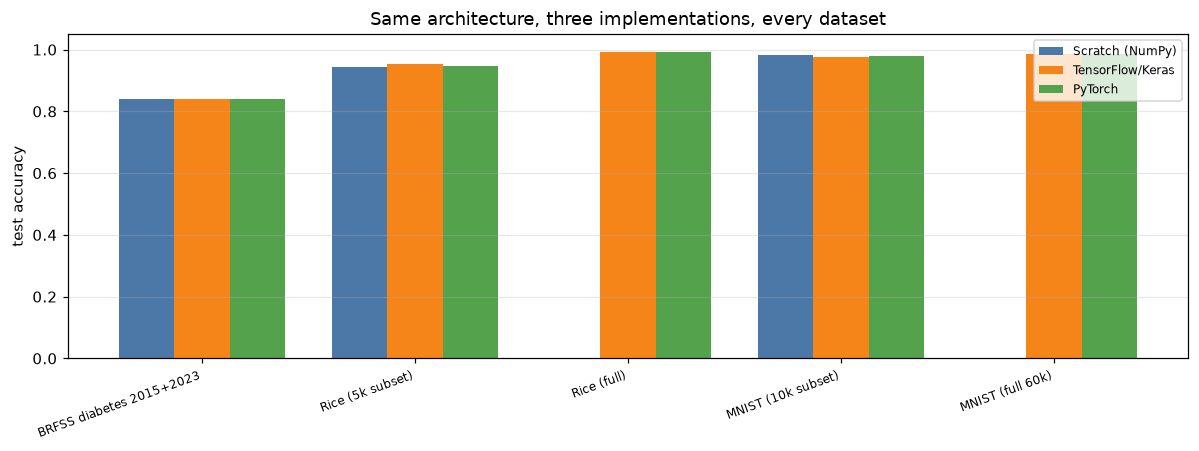

In [5]:
fig, ax = plt.subplots(figsize=(11, 4.2))
datasets = list(all_runs["dataset"].unique())
frameworks = ["Scratch (NumPy)", "TensorFlow/Keras", "PyTorch"]
colors = {"Scratch (NumPy)": "#4C78A8", "TensorFlow/Keras": "#F58518", "PyTorch": "#54A24B"}

width = 0.26
for i, fw in enumerate(frameworks):
    xs, ys = [], []
    for j, ds in enumerate(datasets):
        sel = all_runs[(all_runs["dataset"] == ds) & (all_runs["framework"] == fw)]
        if len(sel):
            xs.append(j + (i - 1) * width)
            ys.append(sel["test_accuracy"].iloc[0])
    ax.bar(xs, ys, width, label=fw, color=colors[fw])

ax.set_xticks(range(len(datasets)), datasets, rotation=20, ha="right", fontsize=8)
ax.set_ylabel("test accuracy"); ax.set_ylim(0, 1.05)
ax.set_title("Same architecture, three implementations, every dataset")
ax.grid(alpha=0.3, axis="y"); ax.legend(fontsize=8)
fig.tight_layout(); plt.show()

---
## 3. What *does* change: cost

Parameter counts and accuracies match. Wall-clock time does not, and not in a single direction.

> **The timings are not measured on equal hardware.** Windows-native TensorFlow has had no GPU build since
> 2.10, so the Keras leg runs on CPU while PyTorch uses the GPU where one is present. A Keras-vs-PyTorch
> time comparison is therefore a comparison of two machines as much as two libraries. The **scratch-vs-
> framework** gap is the honest one: both run on CPU.

In [6]:
pivot = all_runs.pivot_table(index="dataset", columns="framework",
                             values="train_seconds", aggfunc="first")
display(pivot.round(1))

print("scratch NumPy vs PyTorch, same data (both legs, one CPU implementation):\n")
for ds, grp in all_runs.groupby("dataset", sort=False):
    s = grp[grp["framework"] == "Scratch (NumPy)"]["train_seconds"]
    t = grp[grp["framework"] == "PyTorch"]["train_seconds"]
    if len(s) and len(t) and t.iloc[0] > 0:
        print(f"  {ds:<28} {s.iloc[0]:>8.1f}s  vs {t.iloc[0]:>7.1f}s   "
              f"= {s.iloc[0] / t.iloc[0]:>5.1f}x slower")

framework,PyTorch,Scratch (NumPy),TensorFlow/Keras
dataset,,,
BRFSS diabetes 2015+2023,74.7,27.5,41.9
MNIST (10k subset),3.4,42.7,6.6
MNIST (full 60k),16.5,NaN,29.4
Rice (5k subset),1.4,67.3,5.1
Rice (full),17.2,NaN,57.5


scratch NumPy vs PyTorch, same data (both legs, one CPU implementation):

  BRFSS diabetes 2015+2023         27.5s  vs    74.7s   =   0.4x slower
  Rice (5k subset)                 67.3s  vs     1.4s   =  47.4x slower
  MNIST (10k subset)               42.7s  vs     3.4s   =  12.4x slower


`theory_notes.md` §4.1 draws the right conclusion from this gap: the frameworks are faster because their
kernels are optimised C/CUDA running in parallel, **not because they use a smarter algorithm**. The
scratch leg computes the same gradients by the same chain rule. What it lacks is twenty years of
implementation engineering.

---
## 4. Accuracy is not always the right score

The two datasets sit at opposite ends of the class-balance spectrum, which makes them a natural pair for
the point `theory_notes.md` §4.2 makes.

,dataset,framework,test_accuracy,f1_macro,accuracy - f1_macro
0,BRFSS diabetes 2015+2023,Scratch (NumPy),0.8403,0.3919,0.4484
1,BRFSS diabetes 2015+2023,TensorFlow/Keras,0.8402,0.3823,0.4580
2,BRFSS diabetes 2015+2023,PyTorch,0.8406,0.3888,0.4518
3,Rice (5k subset),Scratch (NumPy),0.9445,0.9444,0.0001
4,Rice (5k subset),TensorFlow/Keras,0.9545,0.9544,0.0001
5,Rice (5k subset),PyTorch,0.9475,0.9477,-0.0002
6,Rice (full),PyTorch,0.9929,0.9929,0.0000
7,Rice (full),TensorFlow/Keras,0.9911,0.9911,0.0000
8,MNIST (10k subset),Scratch (NumPy),0.9810,0.9810,0.0000
9,MNIST (10k subset),TensorFlow/Keras,0.9755,0.9756,-0.0001


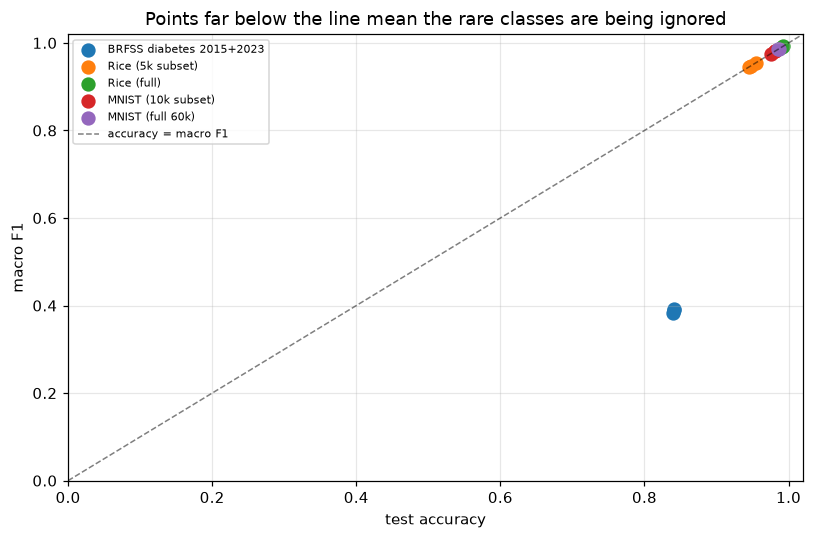

In [7]:
gap = all_runs.copy()
gap["accuracy - f1_macro"] = gap["test_accuracy"] - gap["f1_macro"]
display(gap[["dataset", "framework", "test_accuracy", "f1_macro",
             "accuracy - f1_macro"]].round(4))

fig, ax = plt.subplots(figsize=(7.5, 5))
for ds in datasets:
    sel = gap[gap["dataset"] == ds]
    ax.scatter(sel["test_accuracy"], sel["f1_macro"], s=70, label=ds)
lims = [0, 1.02]
ax.plot(lims, lims, "k--", lw=1, alpha=0.5, label="accuracy = macro F1")
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel("test accuracy"); ax.set_ylabel("macro F1")
ax.set_title("Points far below the line mean the rare classes are being ignored")
ax.grid(alpha=0.3); ax.legend(fontsize=7)
fig.tight_layout(); plt.show()

In [8]:
if n01 and "baseline" in n01:
    b = n01["baseline"]
    print(f"BRFSS trivial baseline ({b['strategy']}):")
    print(f"  accuracy {b['test_accuracy']:.4f}   macro-F1 {b['f1_macro']:.4f}")
    best = all_runs[all_runs["notebook"] == "01_diabetes_brfss"]["test_accuracy"].max()
    print(f"  best trained model accuracy: {best:.4f}  ({best - b['test_accuracy']:+.4f})")
    print("\n  An 84%-accurate model that never predicts 'diabetes' is worthless for screening.")
    print("  That is why macro F1 is the headline number on this dataset.")

if n01 and n01.get("class_weighting"):
    print("\nWhat class weighting traded (section 7 of notebook 01):\n")
    display(pd.DataFrame(n01["class_weighting"]).round(4))

BRFSS trivial baseline (always predict 'no diabetes'):
  accuracy 0.8341   macro-F1 0.3032
  best trained model accuracy: 0.8406  (+0.0064)

  An 84%-accurate model that never predicts 'diabetes' is worthless for screening.
  That is why macro F1 is the headline number on this dataset.

What class weighting traded (section 7 of notebook 01):



,framework,class_weighted,test_accuracy,f1_macro
0,TensorFlow/Keras,no,0.8402,0.3823
1,TensorFlow/Keras,yes,0.5922,0.4130
2,PyTorch,no,0.8406,0.3888
3,PyTorch,yes,0.6550,0.4306


---
## 5. Model family follows data structure

The assignment's other claim: a CNN is a choice justified by a property of the input, not a default.

In [9]:
structure = pd.DataFrame([
    ["BRFSS diabetes", "tabular", "no",
     "MLP (Dense only)", "no spatial neighbourhood for a kernel to exploit"],
    ["Rice images", "image 3x32x32", "yes",
     "CNN (Conv + Pool)", "adjacent pixels belong to the same grain edge"],
    ["MNIST", "image 1x28x28", "yes",
     "CNN (2 conv blocks)", "strokes are local: the same edge detector works anywhere"],
], columns=["dataset", "input", "local structure?", "model family", "why"])
display(structure)

print("Cost of ignoring this, on the rice images (theory_notes 2.1):\n")
flat_mlp = 32 * 32 * 3 * 1024 + 1024
rice_cnn = all_runs[all_runs["notebook"] == "02_rice_cnn"]["n_params"].iloc[0]
print(f"  Flatten -> Dense(1024) first layer alone : {flat_mlp:>10,} parameters")
print(f"  the entire CNN actually used             : {rice_cnn:>10,} parameters")
print(f"  ratio                                    : {flat_mlp / rice_cnn:>10.1f}x")

,dataset,input,local structure?,model family,why
0,BRFSS diabetes,tabular,no,MLP (Dense only),no spatial neighbourhood for a kernel to exploit
1,Rice images,image 3x32x32,yes,CNN (Conv + Pool),adjacent pixels belong to the same grain edge
2,MNIST,image 1x28x28,yes,CNN (2 conv blocks),strokes are local: the same edge detector work...


Cost of ignoring this, on the rice images (theory_notes 2.1):

  Flatten -> Dense(1024) first layer alone :  3,146,752 parameters
  the entire CNN actually used             :    544,453 parameters
  ratio                                    :        5.8x


---
## 6. Improving the architecture — does the CIFAR-10 story repeat?

Notebook 04 reran the M1→M4 ladder from `theory_notes.md` §3.3 on the rice images. The comparison below is
between two *different datasets*, so the accuracies are not comparable in absolute terms — only the
**shape of the ranking** is.

In [10]:
if n04 is None:
    print("run 04_improved_cnn.ipynb to fill this section")
else:
    ladder = n04["ladder"]
    ref = n04["cifar10_reference"]

    comp = pd.DataFrame([{
        "model": r["model"],
        "n_params": r["n_params"],
        f"accuracy ({n04['dataset']})": r["test_accuracy"],
        "vs M1": round(100 * (r["test_accuracy"] - ladder[0]["test_accuracy"]), 2),
        "accuracy (CIFAR-10, notes 3.3)": ref.get(r["model"].split()[0]),
    } for r in ladder])
    comp["vs M1 (CIFAR-10)"] = (
        100 * (comp["accuracy (CIFAR-10, notes 3.3)"] - ref["M1"])).round(2)
    display(comp.round(4))

    rice_best = max(ladder, key=lambda r: r["test_accuracy"])["model"].split()[0]
    cifar_best = max(["M1", "M2", "M3", "M4"], key=lambda k: ref[k])
    print(f"\nbest on rice      : {rice_best}")
    print(f"best on CIFAR-10  : {cifar_best}")
    print("same winner" if rice_best == cifar_best
          else "different winner - the ranking did NOT transfer unchanged")

,model,n_params,accuracy (Rice (4k subset)),vs M1,"accuracy (CIFAR-10, notes 3.3)",vs M1 (CIFAR-10)
0,M1 Conv+ReLU+Pool,72405,0.8015,0.0,0.6947,0.00
1,M2 + BatchNorm,72629,0.9895,18.8,0.7524,5.77
2,M3 + Residual,75461,0.9895,18.8,0.7639,6.92
3,M4 + Attention(SE),78289,0.9945,19.3,0.7367,4.20



best on rice      : M4
best on CIFAR-10  : M3
different winner - the ranking did NOT transfer unchanged


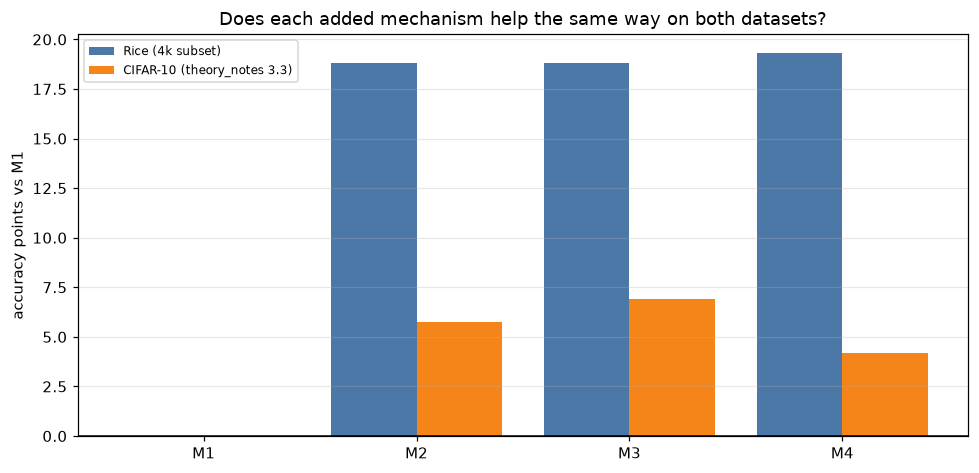

data augmentation, for zero extra parameters: -1.20 accuracy points


In [11]:
if n04 is not None:
    ladder = n04["ladder"]
    ref = n04["cifar10_reference"]
    fig, ax = plt.subplots(figsize=(9, 4.4))
    keys = [r["model"].split()[0] for r in ladder]
    x = np.arange(len(keys))
    rice_d = [100 * (r["test_accuracy"] - ladder[0]["test_accuracy"]) for r in ladder]
    cif_d = [100 * (ref[k] - ref["M1"]) for k in keys]
    ax.bar(x - 0.2, rice_d, 0.4, label=n04["dataset"], color="#4C78A8")
    ax.bar(x + 0.2, cif_d, 0.4, label="CIFAR-10 (theory_notes 3.3)", color="#F58518")
    ax.axhline(0, color="k", lw=1)
    ax.set_xticks(x, keys)
    ax.set_ylabel("accuracy points vs M1")
    ax.set_title("Does each added mechanism help the same way on both datasets?")
    ax.grid(alpha=0.3, axis="y"); ax.legend(fontsize=8)
    fig.tight_layout(); plt.show()

    aug = n04["augmentation"]
    d = aug[1]["test_accuracy"] - aug[0]["test_accuracy"]
    print(f"data augmentation, for zero extra parameters: {100 * d:+.2f} accuracy points")

---
## 7. Where each component lives (slide 28)

Each notebook filled this in for itself; they agree, because the mapping is a property of the three
libraries rather than of any dataset.

In [12]:
display(pd.DataFrame(n02["component_table"]))

,Component,Scratch,TensorFlow/Keras,PyTorch
0,Data loading,ass4_newdata -> NumPy arrays,same arrays (transposed to NHWC),same arrays
1,Preprocessing,ass4_newdata (shared),shared,shared
2,Tensor layout,"N,C,H,W","N,H,W,C (channels-last)","N,C,H,W"
3,Model definition,S.Sequential([...]),keras.Sequential([...]),nn.Module
4,Convolution,S.Conv2D (im2col by hand),keras.layers.Conv2D,nn.Conv2d
5,Pooling,S.MaxPool2D (argmax routing),keras.layers.MaxPooling2D,nn.MaxPool2d
6,Activation,S.ReLU (mask multiply),activation='relu',nn.ReLU
7,Flatten,S.Flatten,keras.layers.Flatten,nn.Flatten
8,Loss,S.SoftmaxCrossEntropy,SparseCategoricalCrossentropy,nn.CrossEntropyLoss
9,Gradient,hand-derived backward(),automatic (GradientTape),automatic (autograd)


---
## 8. Against the original three datasets

The repository root holds `results/all_runs.csv` from the first six notebooks — Diabetes 130-US, MNIST and
CIFAR-10. Six datasets across the two collections is a much stronger test of "the framework does not change
the model" than three.

In [13]:
old_csv = os.path.join(D.ROOT, "results", "all_runs.csv")
if not os.path.exists(old_csv):
    print("results/all_runs.csv not found - skipping the historical comparison")
else:
    old = pd.read_csv(old_csv)
    old["collection"] = "original"
    new = all_runs.drop(columns=["notebook"]).copy()
    new["collection"] = "new data"
    both = pd.concat([old[new.columns.intersection(old.columns).tolist()],
                      new], ignore_index=True)

    print("framework accuracy spread within each dataset, both collections:\n")
    out = []
    for (coll, ds), grp in both.groupby(["collection", "dataset"], sort=False):
        if grp["framework"].nunique() < 2:
            continue
        out.append({"collection": coll, "dataset": ds,
                    "frameworks": grp["framework"].nunique(),
                    "spread": grp["test_accuracy"].max() - grp["test_accuracy"].min()})
    out = pd.DataFrame(out).sort_values("spread", ascending=False)
    display(out.round(4))
    print(f"\nlargest spread across all {len(out)} dataset/collection pairs: "
          f"{out['spread'].max():.4f}")
    print("Noise floor measured by seed alone in the original 04_compare.ipynb: 0.053")

framework accuracy spread within each dataset, both collections:



,collection,dataset,frameworks,spread
4,original,CIFAR-10 (full 50k),2,0.0692
3,original,CIFAR-10 (5k subset),3,0.0430
6,new data,Rice (5k subset),3,0.0100
1,original,MNIST (10k subset),3,0.0080
8,new data,MNIST (10k subset),3,0.0055
0,original,Diabetes 130-US hospitals,3,0.0029
2,original,MNIST (full 60k),2,0.0020
7,new data,Rice (full),2,0.0018
9,new data,MNIST (full 60k),2,0.0012
5,new data,BRFSS diabetes 2015+2023,3,0.0003



largest spread across all 10 dataset/collection pairs: 0.0692
Noise floor measured by seed alone in the original 04_compare.ipynb: 0.053


---
## 9. Conclusions

**The framework does not change the model.** Across two collections and six datasets, three implementations
of one architecture produced identical parameter counts, identical tensor shapes at every stage, and
accuracies separated by less than the seed-only noise floor. `S.Dense`, `keras.layers.Dense` and
`nn.Linear` are three names for one function; `S.Conv2D`, `keras.layers.Conv2D` and `nn.Conv2d` are three
names for another.

**What changes is visibility.** The scratch leg makes `Forward → Loss → Gradient → Update` explicit and has
to derive its own gradients — verified against central finite differences in every notebook that uses it.
Keras hides the loop, the gradient and the update behind `fit()`. PyTorch keeps a compact model definition
but an explicit loop, with autograd underneath. Choose the abstraction that matches what you need to see.

**What changes is cost, and not in one direction.** The scratch implementation is roughly an order of
magnitude slower than the frameworks on identical CPU work — the price of readable NumPy instead of tuned
kernels. But on the small tabular MLP, moving to a GPU does not help either: each batch carries too little
arithmetic to pay for the transfer.

**The model should match the structure of the data.** No convolution appears in notebook 01, because
survey answers have no spatial neighbourhood. Convolution appears in 02 and 03 because pixels do, and it
buys a 5-times reduction in parameters over even the first layer of a flattened MLP.

**The metric should match the structure of the labels.** Balanced rice and MNIST images make accuracy trustworthy;
an 84/2/14 BRFSS split makes it actively misleading, and macro F1 is what exposes a model that has learned
the prior rather than the problem.

**Adding a mechanism does not guarantee an improvement.** Section 6 checks whether the M1→M4 ranking from
`theory_notes.md` §3.3 reproduced on different data. Whatever the answer, it was *measured* rather than
assumed — which is the actual lesson of that section.

**Finally, an incomplete dataset is a finding, not an obstacle.** The Intel scene data arrived without its
labelled splits. `00_inventory.ipynb` detected that before a single epoch was trained, notebook 03 refuses
to run rather than inventing numbers, and every table here is explicit about what is missing. Checking the
data before trusting it is the cheapest step in the whole pipeline.